# 树叶分类


In [1]:
import torch
import torchvision
from torch import nn
import util
import kagglehub
import os
from pathlib import Path
import pandas as pd
import numpy as np

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


## 整理数据集


获得训练、测试的图片集


In [2]:
path = Path('./data/classify-leaves')
train_csv = pd.read_csv(path/'train.csv')
test_csv = pd.read_csv(path/'test.csv')

only_name = lambda x: x.split('/')[-1]
train_csv = train_csv.assign(image=train_csv['image'].apply(only_name))
test_csv = test_csv.assign(image=test_csv['image'].apply(only_name))

train_names = train_csv['image'].values
train_labels = train_csv['label'].values
test_names = test_csv['image'].values

整理文件夹

In [3]:
def to_dir(names, folder):
    for name in names:
        src = path/'images'/name
        dst = path/folder/name
        os.makedirs(dst.parent, exist_ok=True)
        if dst.exists():
            continue
        if not src.exists():
            print(f'Warning: {src} does not exist.')
            continue
        os.link(src, dst)
to_dir(train_names, 'train')
to_dir(test_names, 'test')

获取标签字典

In [4]:
rid_subfix = lambda x: x.split('.')[0]
labels = train_csv.assign(image=train_csv['image'].apply(rid_subfix))
labels.to_csv(path/'labels.csv', index=False)

按分类整理文件夹

In [5]:
util.data.reorg_data(path, 'labels.csv', 0.1)

## 数据增强

In [6]:
train_aug = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(224),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ToTensor()
])
test_aug = torchvision.transforms.Compose([
    torchvision.transforms.Resize(256),
    torchvision.transforms.CenterCrop(224),
    torchvision.transforms.ToTensor()
])

In [25]:
train_ds, train_valid_ds, valid_ds, test_ds = util.data.get_dataset(path, train_aug, test_aug)
train_iter, train_valid_iter, valid_iter, test_iter = util.data.get_dataloader(train_ds, train_valid_ds,
                                                                               valid_ds, test_ds,
                                                                               batch_size=64)

## 模型

In [8]:
def get_net():
    net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, 176)
    nn.init.xavier_normal_(net.fc.weight)
    return net

In [9]:
def train(net,
          train_iter, valid_iter,
          num_epochs,
          lr, wd,
          devices,
          lr_period, lr_decay,
          finetune=True):
    if finetune:
        trainer = torch.optim.Adam([
            {'params': [param for name, param in net.named_parameters() if name not in ['fc.weight', 'fc.bias']]},
            {'params': net.fc.parameters(), 'lr': lr * 10}
        ], lr=lr, weight_decay=wd)
    else:
        trainer = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, step_size=lr_period, gamma=lr_decay)
    loss = nn.CrossEntropyLoss(reduce='none')
    num_batches = len(train_iter)
    timer = util.Timer()
    legend = ['train loss', 'train acc']
    if valid_iter is not None:
        legend.append('valid acc')
    animator = util.Animator(xlabel='epoch', xlim=[1, num_epochs], legend=legend, ylim=[0.2, 1])
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])
    for epoch in range(num_epochs):
        net.train()
        metric = util.Accumulator(3)
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            l, acc = util.train.train_batch_ch13(net, X, y, loss, trainer, devices)
            metric.add(l, acc, y.shape[0])
            timer.stop()
            # 每个 epoch 画两次
            if (i + 1) % (num_batches // 2) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (metric[0] / metric[2], metric[1] / metric[2], None))
        if valid_iter is not None:
            valid_acc = util.train.evaluate_accuracy_gpu(net, valid_iter)
            animator.add(epoch + 1, (None, None, valid_acc))
        scheduler.step()
    measures = (f'train loss {metric[0] / metric[2]:.3f}, ',
                f'train acc {metric[1] / metric[2]:.3f}')
    if valid_iter is not None:
        measures += (f'valid acc {valid_acc:.3f}, ',)
    print(measures + (f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(devices)}',))

训练

('train loss 0.003, ', 'train acc 0.943', 'valid acc 0.995, ', "3285.8 examples/sec on [device(type='cuda', index=0)]")


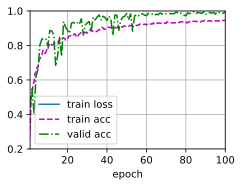

In [10]:
devices = util.try_all_gpus()
lr = 5e-4
wd = 1e-4
num_epochs = 100
lr_period = 5
lr_decay = 0.9
net = get_net()
train(net, train_iter, valid_iter, num_epochs, lr, wd, devices, lr_period, lr_decay, finetune=True)

预测

In [26]:
def predict(net, test_iter):
    preds = []
    for X, _ in test_iter:
        y_hat = net(X.to(devices[0]))
        y_hat = y_hat.argmax(axis=1)
        preds.extend(y_hat.type(torch.int32).cpu().numpy())
        if len(preds) % 2000 == 0:
            print(f'Processed {len(preds)} examples, {len(test_iter.dataset)-len(preds)} left')
    sorted_ids = list(test_names)
    sorted_ids.sort(key=lambda x: str(x))
    df = pd.DataFrame({'image': sorted_ids, 'label': preds})
    df['label'] = df['label'].map(lambda x: train_valid_ds.classes[x])
    return df

pred = predict(net, test_iter)
def add_fix(x):
    return 'images/' + str(x)
pred = pred.assign(image=pred['image'].apply(add_fix))
pred.to_csv(path/'submission.csv', index=False)

Processed 8000 examples, 800 left
